In [62]:
# %pip install nflreadpy *UNCOMMENT/RUN ONLY ONCE TO INSTALL ON YOUR MACHINE* 
# %pip install adjustText *UNCOMMENT/RUN ONLY ONCE TO INSTALL ON YOUR MACHINE*

import nflreadpy as nfl
import pandas as pd
import networkx as nx
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Load play-by-play data into memory
pbp_raw = nfl.load_pbp([2024, 2025, 2026])

# 2. Select only relevant columns in Polars to reduce memory before conversion
KEEP_COLS = [
    'game_id', 'play_id', 'season', 'week', 'posteam', 'defteam',
    'passer_player_id', 'passer_player_name',
    'receiver_player_id', 'receiver_player_name',
    'play_type', 'complete_pass', 'sack',
    'epa', 'yards_gained', 'air_yards', 'yards_after_catch',
    'air_epa', 'yac_epa', 'success', 'first_down_pass'
]

pbp_trimmed = pbp_raw.select(KEEP_COLS)

# 3. Convert lightweight Polars DataFrame -> Pandas DataFrame
df = pbp_trimmed.to_pandas()

# 4. Filter for completed passes
passing_df = df[
    (df['play_type'] == 'pass') & 
    (df['complete_pass'] == 1) & 
    (df['sack'] == 0) &
    (df['passer_player_name'].notna()) & 
    (df['receiver_player_name'].notna())
]

# 5. Aggregate metrics by passer-receiver duo
edge_df = passing_df.groupby(
    ['passer_player_name', 'receiver_player_name'], 
    as_index=False
).agg(
    mean_epa=('epa', 'mean'),
    total_epa=('epa', 'sum'),
    completions=('epa', 'count'),
    mean_yards=('yards_gained', 'mean'),
    mean_air_yards=('air_yards', 'mean'), 
    games_played=('game_id', 'nunique')
)
edge_df['epa_per_game'] = edge_df['total_epa'] / edge_df['games_played']

# 6. Apply minimum completion threshold
edge_df = edge_df[edge_df['completions'] >= 50]

# 7. Construct NetworkX Graph
G = nx.from_pandas_edgelist(
    edge_df,
    source='passer_player_name',
    target='receiver_player_name',
    edge_attr=['mean_epa', 'total_epa', 'completions', 'mean_yards', 'mean_air_yards', 'games_played', 'epa_per_game'],
    create_using=nx.Graph()
)
print(f"Active Player Nodes: {G.number_of_nodes()}")
print(f"Passer-Receiver Edges: {G.number_of_edges()}")

Active Player Nodes: 164
Passer-Receiver Edges: 145


In [63]:
# 8. Identify true QBs (players with at least 10 pass completions in the dataset)
qb_completions = df[
    (df['play_type'] == 'pass') & 
    (df['complete_pass'] == 1)
].groupby('passer_player_name')['play_id'].count()

primary_qbs = set(qb_completions[qb_completions >= 10].index)

# 9. Extract edge data with guaranteed Passer -> Receiver orientation
edges_data = []
for u, v, d in G.edges(data=True):
    # If 'v' is a primary QB and 'u' is not, swap so QB is always listed under 'Passer'
    if v in primary_qbs and u not in primary_qbs:
        passer, receiver = v, u
    else:
        passer, receiver = u, v
        
    edges_data.append({
        'Passer': passer,
        'Receiver': receiver,
        'Total_EPA': d['total_epa'],
        'EPA_Per_Game': d['epa_per_game'],
        'Mean_EPA': d['mean_epa'],
        'Completions': d['completions'],
        'Games': d['games_played'],
        'Avg_Yards': d['mean_yards']
    })

results_df = pd.DataFrame(edges_data)
results_df = results_df[results_df['Games'] >= 20] # Filter for minimum games played (e.g., Games >= 20)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

In [64]:
# 10. Generate first output table
game_efficiency = results_df.sort_values(by='EPA_Per_Game', ascending=False).head(15)[
    ['Passer', 'Receiver', 'EPA_Per_Game', 'Total_EPA', 'Mean_EPA', 'Completions', 'Games']
].rename(columns={
    'EPA_Per_Game': 'EPA / Game',
    'Total_EPA': 'Total EPA',
    'Mean_EPA': 'EPA / Completion'
})

(game_efficiency.style
    .format({
        'EPA / Game': '{:.2f}',
        'Total EPA': '{:.1f}',
        'Completions': '{:d}',
        'Games': '{:d}'
    })
    .background_gradient(subset=['EPA / Game'], cmap='Oranges')
    .set_caption("Top 15 NFL Passer-Receiver Duos (2024-) by Average Game Value (EPA / Game)")
    .hide(axis='index')
    .set_properties(**{
        'padding': '4px 10px',
        'text-align': 'center',
        'font-size': '11.5px',
        'border-bottom': '1px solid #e0e0e0'
    })
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '6px'),
            ('color', '#333333')
        ]},
        {'selector': 'th', 'props': [
            ('padding', '6px 10px'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('font-size', '12px'),
            ('background-color', '#f8f9fa'),
            ('border-bottom', '2px solid #cccccc')
        ]}
    ])
)

Passer,Receiver,EPA / Game,Total EPA,EPA / Completion,Completions,Games
M.Stafford,P.Nacua,8.07,266.2,1.073222,248,33
J.Burrow,J.Chase,7.63,213.5,1.083883,197,28
J.Goff,A.St. Brown,7.62,282.0,1.076424,262,37
S.Darnold,J.Smith-Njigba,7.57,166.5,1.132802,147,22
D.Prescott,G.Pickens,7.48,149.6,1.384989,108,20
J.Burrow,T.Higgins,7.27,152.8,1.376163,111,21
D.Prescott,C.Lamb,6.66,159.7,1.101543,145,24
M.Stafford,D.Adams,6.25,125.0,1.404483,89,20
J.Hurts,A.Brown,6.19,192.0,1.288414,149,31
C.Stroud,N.Collins,6.08,170.2,1.270408,134,28


In [65]:
# 11. Generate second output table
total_efficiency = results_df.sort_values(by='Total_EPA', ascending=False).head(15)[
    ['Passer', 'Receiver', 'EPA_Per_Game', 'Total_EPA', 'Mean_EPA', 'Completions', 'Games']
].rename(columns={
    'Total_EPA': 'Total EPA',
    'EPA_Per_Game': 'EPA / Game',
    'Mean_EPA': 'EPA / Completion'
})

(total_efficiency.style
    .format({
        'Total EPA': '{:.1f}',
        'EPA / Game': '{:.2f}',
        'Completions': '{:d}',
        'Games': '{:d}'
    })
    .background_gradient(subset=['Total EPA'], cmap='Blues')
    .set_caption("Top 15 NFL Passer-Receiver Duos (2024-) by Cumulative Value (Total EPA)")
    .hide(axis='index')
    .set_properties(**{
        'padding': '4px 10px',
        'text-align': 'center',
        'font-size': '11.5px',
        'border-bottom': '1px solid #e0e0e0'
    })
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '6px'),
            ('color', '#333333')
        ]},
        {'selector': 'th', 'props': [
            ('padding', '6px 10px'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('font-size', '12px'),
            ('background-color', '#f8f9fa'),
            ('border-bottom', '2px solid #cccccc')
        ]}
    ])
)

Passer,Receiver,EPA / Game,Total EPA,EPA / Completion,Completions,Games
J.Goff,A.St. Brown,7.62,282.0,1.076424,262,37
M.Stafford,P.Nacua,8.07,266.2,1.073222,248,33
B.Nix,C.Sutton,5.67,215.4,1.252150,172,38
J.Burrow,J.Chase,7.63,213.5,1.083883,197,28
J.Herbert,L.McConkey,5.36,198.4,1.160301,171,37
J.Hurts,A.Brown,6.19,192.0,1.288414,149,31
J.Hurts,D.Smith,5.15,185.4,1.065354,174,36
L.Jackson,Z.Flowers,5.52,176.6,1.252641,141,32
P.Mahomes,T.Kelce,4.73,170.4,0.901543,189,36
C.Stroud,N.Collins,6.08,170.2,1.270408,134,28


In [66]:
# 12. Generate third output table
play_efficiency = results_df.sort_values(by='Mean_EPA', ascending=False).head(15)[
    ['Passer', 'Receiver', 'EPA_Per_Game', 'Total_EPA', 'Mean_EPA', 'Completions', 'Games']
].rename(columns={
    'Mean_EPA': 'EPA / Completion',
    'EPA_Per_Game': 'EPA / Game',
    'Total_EPA': 'Total EPA'
})

(play_efficiency.style
    .format({
        'EPA / Completion': '{:.2f}',
        'EPA / Game': '{:.2f}',
        'Completions': '{:d}',
        'Games': '{:d}'
    })
    .background_gradient(subset=['EPA / Completion'], cmap='YlGn')
    .set_caption("Top 15 NFL Passer-Receiver Duos (2024-) by  Average Completion Value")
    .hide(axis='index')
    .set_properties(**{
        'padding': '4px 10px',
        'text-align': 'center',
        'font-size': '11.5px',
        'border-bottom': '1px solid #e0e0e0'
    })
    .set_table_styles([
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '6px'),
            ('color', '#333333')
        ]},
        {'selector': 'th', 'props': [
            ('padding', '6px 10px'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('font-size', '12px'),
            ('background-color', '#f8f9fa'),
            ('border-bottom', '2px solid #cccccc')
        ]}
    ])
)

Passer,Receiver,EPA / Game,Total EPA,EPA / Completion,Completions,Games
J.Love,C.Watson,5.32,117.098840,1.56,75,22
L.Jackson,R.Bateman,4.19,113.123929,1.51,75,27
J.Goff,J.Williams,5.73,160.498913,1.47,109,28
B.Young,T.McMillan,5.62,112.391487,1.42,79,20
M.Stafford,D.Adams,6.25,124.999008,1.40,89,20
K.Cousins,D.Mooney,4.91,103.191586,1.39,74,21
D.Prescott,G.Pickens,7.48,149.578771,1.38,108,20
J.Daniels,T.McLaurin,5.35,133.629528,1.38,97,25
J.Burrow,T.Higgins,7.27,152.754143,1.38,111,21
C.Williams,R.Odunze,4.48,143.409527,1.35,106,32


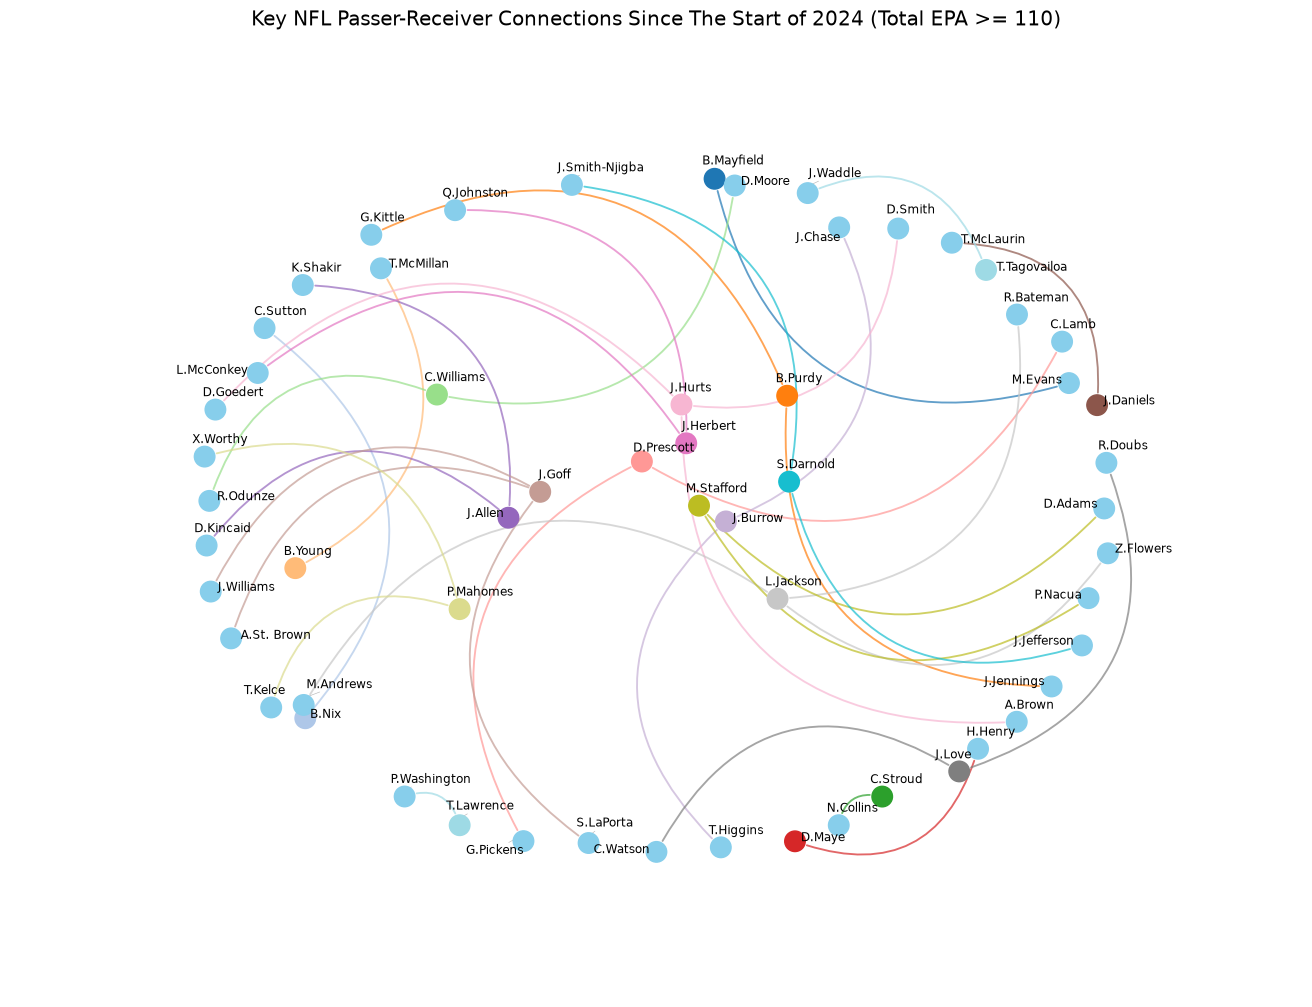

In [67]:
# 13. Generate network visual
top_edges = edge_df[edge_df['total_epa'] >= 110]
G_sub = nx.from_pandas_edgelist(
    top_edges, 
    source='passer_player_name', 
    target='receiver_player_name', 
    edge_attr='total_epa',
    create_using=nx.DiGraph()  # Ensures clear Passer (source) -> Receiver (target) direction
)

plt.figure(figsize=(16, 12))
ax = plt.gca()

# Force-directed layout with high 'k' value to spread out clusters naturally
pos = nx.spring_layout(G_sub, k=2.2, iterations=150, seed=42)

# Assign a distinct color to each QB/Passer
passers = sorted(list(set(top_edges['passer_player_name'])))
cmap = plt.colormaps['tab20'].resampled(len(passers))
qb_colors = {qb: cmap(i) for i, qb in enumerate(passers)}

# Map node colors: QB nodes get their specific color; Receivers remain skyblue
node_colors = [qb_colors[node] if node in qb_colors else 'skyblue' for node in G_sub.nodes()]

# Map edge colors to match the QB (source passer)
edge_colors = [qb_colors.get(u, (0.6, 0.6, 0.6, 0.5)) for u, v in G_sub.edges()]

# Draw nodes with QB color-coding
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=200, ax=ax)

# Draw curved edges matching QB color-coding
nx.draw_networkx_edges(
    G_sub, pos, 
    edge_color=edge_colors, 
    width=1.3, 
    alpha=0.7,
    arrows=True, 
    arrowstyle='-', 
    connectionstyle="arc3,rad=0.53", 
    ax=ax
)

# Extract node x,y points to treat them as obstacles
node_x = [coords[0] for coords in pos.values()]
node_y = [coords[1] for coords in pos.values()]

# Place text objects
texts = []
for node, (x, y) in pos.items():
    texts.append(ax.text(x, y + 0.02, node, fontsize=8, ha='center', va='center', fontweight='normal'))

# Repel text labels away from each other AND away from node dots
adjust_text(
    texts,
    x=node_x,
    y=node_y,
    expand=(1.5, 1.8),
    force_text=(0.3, 0.5),
    arrowprops=dict(arrowstyle="-", color='gray', lw=0.4, alpha=0.6)  # Adds a subtle pointer line if a label moves far from its node
)

plt.margins(0.15)
plt.title("Key NFL Passer-Receiver Connections Since The Start of 2024 (Total EPA >= 110)", fontsize=14)
plt.axis('off')
plt.show()